In [55]:
# 获取环境，导库，配置画图面板，导入数据，
# 使用mysql的连接数据库的步骤是，使用pymysql.connect建立连接，使用read_sql方法读取数据,直接用变量保存datafram类型数据，方便后续分析


# pandas: 数据分析的核心库，DataFrame = 内存中的表格
#         命名习惯: import pandas as pd → 后面用 pd.read_sql()、pd.DataFrame()
import pandas as pd

# numpy: 科学计算库，提供高效的数组运算
#         np.select() 向量化条件判断、np.log() 对数变换等
import numpy as np

# matplotlib: Python 最基础的绑图库
#             matplotlib.pyplot 提供类似 MATLAB 的绑图 API
import matplotlib.pyplot as plt
# mticker: 刻度格式化工具，比如把 1000000 显示为 "1,000,000"
import matplotlib.ticker as mticker

# seaborn: 基于 matplotlib 的高级可视化库
#          默认样式比 matplotlib 好看，sns.set_theme() 一键设置全局风格
import seaborn as sns

# datetime: 处理日期时间，datetime.now() 获取当前时间
from datetime import datetime

# 解决字体和负号问题
sns.set_theme(style='whitegrid', context='talk', font='Microsoft YaHei')
# 解决 matplotlib 中文字体下负号显示为方框的问题
plt.rcParams['axes.unicode_minus'] = False

import pymysql
# 与mysql建立连接，之后获取要使用的两张表
conn = pymysql.connect(host='localhost', user='root', password='123456', database='ecommerce_analysis', charset='utf8mb4')
T_USER_BEHAVIOR, T_ORDERS = 'user_behavior', 'orders'
user_behavior_df = pd.read_sql(f'SELECT * FROM {T_USER_BEHAVIOR}', conn)
orders_df = pd.read_sql(f'SELECT * FROM {T_ORDERS}', conn)
# 修改两站表的时间数据类型
user_behavior_df['create_time'] = pd.to_datetime(user_behavior_df['create_time'])
orders_df['create_time'] = pd.to_datetime(orders_df['create_time'])

print(f'用户行为数据: {len(user_behavior_df):,} 条')
print(f'订单数据:     {len(orders_df):,} 条')

C:\Users\96181\AppData\Local\Temp\ipykernel_7636\407956885.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  user_behavior_df = pd.read_sql(f'SELECT * FROM {T_USER_BEHAVIOR}', conn)


用户行为数据: 27,897 条
订单数据:     1,851 条


C:\Users\96181\AppData\Local\Temp\ipykernel_7636\407956885.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql(f'SELECT * FROM {T_ORDERS}', conn)


In [56]:
user_behavior_df.head()

,id,user_id,action,product_id,create_time
0,1,655,view,30,2025-01-01
1,2,655,add_to_cart,30,2025-01-01
2,3,282,view,97,2025-01-01
3,4,143,view,31,2025-01-01
4,5,143,add_to_cart,31,2025-01-01


In [57]:
orders_df.head()

,order_id,user_id,amount,order_status,create_time
0,1,433,74.15,completed,2025-01-01
1,2,239,528.12,paid,2025-01-01
2,3,734,118.71,completed,2025-01-01
3,4,829,51.49,cancelled,2025-01-01
4,5,7,231.72,paid,2025-01-01


In [58]:
# 展示用户行为日志中每一种交易类型的具体数值
user_behavior_df['action'].value_counts()

action
view           18931
add_to_cart     5711
place_order     1898
pay             1357
Name: count, dtype: int64

In [59]:
# 按照每个月份进行划分，就是每个月份的漏斗分析


In [60]:
# 日pv,uv计算
# 首先构建一个每日pv，uv的表，默认会将分组的时间当作索引，所以使用reset_index()方法将索引变为普通列，之后使用rename将列名变为date
pv_uv_df = user_behavior_df.groupby(user_behavior_df['create_time'].dt.date).agg(pv=('id', 'count'), uv=('user_id', 'nunique')).reset_index().rename(columns={'create_time': 'date'})

# 计算平均值
avg_pv = pv_uv_df['pv'].mean()
avg_uv = pv_uv_df['uv'].mean()  
print(f'日均 PV: {avg_pv:,.0f}')
print(f'日均 UV: {avg_uv:,.0f}')

# 计算pv/uv比，可以展示每个用户 逛得深不深
print(f'PV/UV 比: {(avg_pv/avg_uv):.1f}（平均每用户浏览页面数）')
pv_uv_df.head(5)

日均 PV: 930
日均 UV: 495
PV/UV 比: 1.9（平均每用户浏览页面数）


,date,pv,uv
0,2025-01-01,1004,531
1,2025-01-02,984,523
2,2025-01-03,1038,531
3,2025-01-04,888,485
4,2025-01-05,802,442


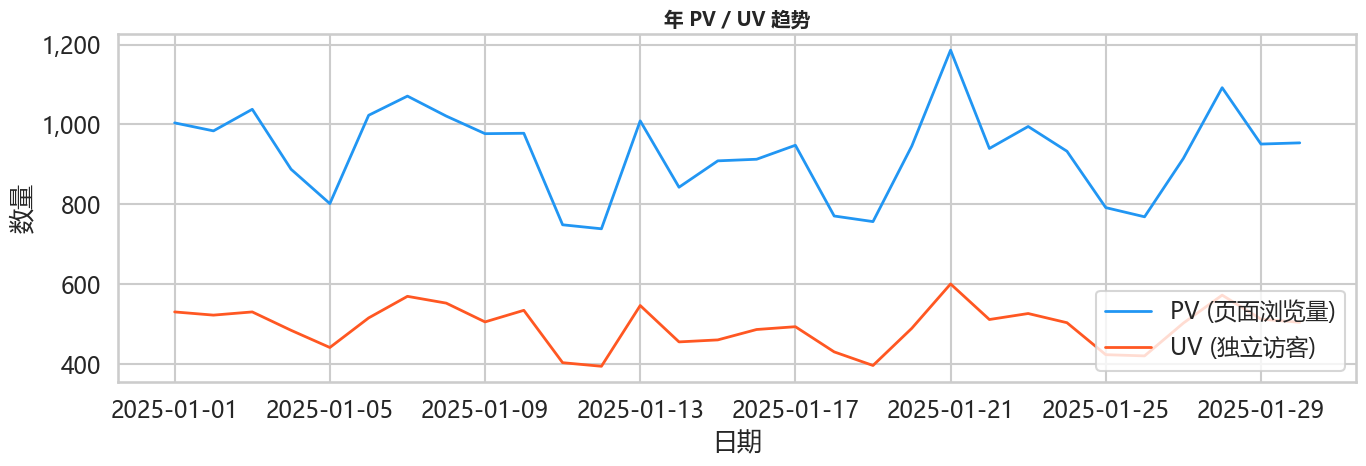

In [61]:
# 绘制整年的pv,uv趋势图
# 创建画板的时候会返回一个元组，fig是设置画板相关的东西，ax设置画布相关的东西
fig , ax = plt.subplots(figsize=(14,5))
ax.plot( pv_uv_df['date'], pv_uv_df['pv'], color='#2196F3', linewidth=2, label='PV (页面浏览量)')
ax.plot( pv_uv_df['date'], pv_uv_df['uv'], color='#FF5722', linewidth=2, label='UV (独立访客)') 
ax.set_title('年 PV / UV 趋势', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('日期')
ax.set_ylabel('数量')
# plt设置画板 tight_layout的作用是让画布不会挤到一起去

plt.tight_layout()
plt.show()


In [62]:
# 付费率分析 ，统计付费的用户有多少人，付费率等于 付费用户/用户数，使用order表中获取(因为订单表才是最终的数据)
len(orders_df)

1851

In [63]:
# 付费率分析绘制两个表，一个是使用user_behavior_df表会知道每一天总体的购买量的表，一个是使用order_df表中筛选下单成功的人数表
# 之后将两张表进行合并，计算付费率

# 创建总人数表
daily_users = (user_behavior_df.groupby(user_behavior_df['create_time'].dt.date)['user_id']
.nunique()
.reset_index(name='total_users')
.rename(columns={'create_time': 'date'})
)
print(daily_users.head())
# 创建付费人数表，只有paid=已付款, shipped=已发货, completed=已完成 → 这些都是"有效订单"
paid = orders_df[orders_df['order_status'].isin(['paid', 'shipped', 'completed'])]
daily_paid = (paid.groupby(paid['create_time'].dt.date)['user_id']
.nunique()
.reset_index(name='paid_users')
.rename(columns={'create_time': 'date'}))
print(daily_paid.head())
# 使用meager将两个表合并
pay_rate_df = pd.merge(daily_users, daily_paid, on='date', how='left')
pay_rate_df['paid_users'] = pay_rate_df['paid_users'].fillna(0).astype(int)
print(pay_rate_df.head())
pay_rate_df['payment_rate'] = pay_rate_df['paid_users'] / pay_rate_df['total_users']
print(pay_rate_df.head())
avg_pay_rate = pay_rate_df['payment_rate'].mean()
print(f'平均日付费率: {pay_rate_df["payment_rate"].mean():.2%}')
print(f'最高付费率:   {pay_rate_df["payment_rate"].max():.2%}')
print(f'最低付费率:   {pay_rate_df["payment_rate"].min():.2%}')

         date  total_users
0  2025-01-01          531
1  2025-01-02          523
2  2025-01-03          531
3  2025-01-04          485
4  2025-01-05          442
         date  paid_users
0  2025-01-01          51
1  2025-01-02          51
2  2025-01-03          58
3  2025-01-04          45
4  2025-01-05          29
         date  total_users  paid_users
0  2025-01-01          531          51
1  2025-01-02          523          51
2  2025-01-03          531          58
3  2025-01-04          485          45
4  2025-01-05          442          29
         date  total_users  paid_users  payment_rate
0  2025-01-01          531          51      0.096045
1  2025-01-02          523          51      0.097514
2  2025-01-03          531          58      0.109228
3  2025-01-04          485          45      0.092784
4  2025-01-05          442          29      0.065611
平均日付费率: 8.95%
最高付费率:   13.23%
最低付费率:   5.27%


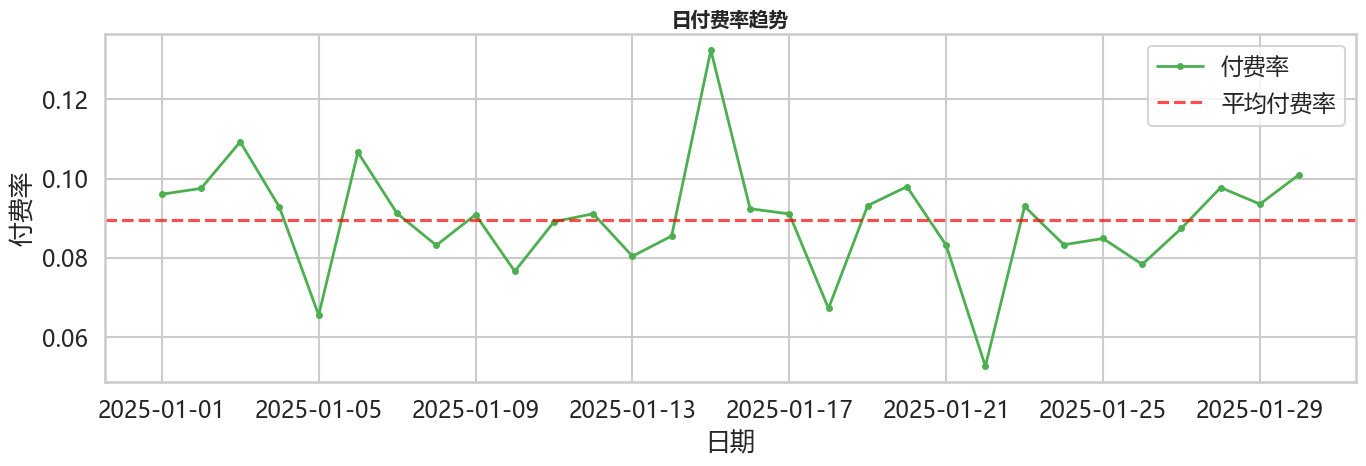

In [64]:
# 构建一个付费趋势图，添加一条平均线
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(pay_rate_df['date'], pay_rate_df['payment_rate'],
        color='#4CAF50', linewidth=2, marker='o', markersize=4,label='付费率')
ax.axhline(pay_rate_df['payment_rate'].mean(), color='red', linestyle='--', alpha=0.7, label='平均付费率')
ax.set_title('日付费率趋势', fontweight='bold', fontsize=14)
ax.legend()
ax.set_xlabel('日期')   
ax.set_ylabel('付费率')
plt.tight_layout()
plt.show()


In [65]:
orders_df.head()

,order_id,user_id,amount,order_status,create_time
0,1,433,74.15,completed,2025-01-01
1,2,239,528.12,paid,2025-01-01
2,3,734,118.71,completed,2025-01-01
3,4,829,51.49,cancelled,2025-01-01
4,5,7,231.72,paid,2025-01-01


In [66]:
# 复购分析，规定大于等于两次购买就可以算作是复购用户,这个复购应该使用用户作为分组

valid_orders = orders_df[orders_df['order_status'].isin(['paid', 'shipped', 'completed'])]
repurchase_df = (valid_orders.groupby('user_id').agg(
    order_count=('order_id', 'nunique'),
    total_amount=('amount', 'sum')
)
.reset_index()
.query('order_count >= 2')
)
repurchase_rate = len(repurchase_df) / orders_df['user_id'].nunique()
print(repurchase_df.head())
print(f'复购用户数：{len(repurchase_df)}')
print(f'复购率：{repurchase_rate:.2%}')
print(f'复购用户人均订单数：{repurchase_df["order_count"].mean():.1f}')
print(f'复购用户人均消费额：{repurchase_df["total_amount"].mean():.0f} 元')
print(repurchase_df['order_count'].value_counts().sort_index())

   user_id  order_count  total_amount
0        2            2         99.03
1        3            3        649.69
4        6            2        551.57
5        7            2        454.05
8       11            2        319.62
复购用户数：395
复购率：46.42%
复购用户人均订单数：2.5
复购用户人均消费额：414 元
order_count
2    256
3     99
4     32
5      5
6      2
7      1
Name: count, dtype: int64


In [67]:
# 构建购买行为的漏斗分析，浏览，加购，下单，支付的宽表，将每一个用户的行为展开表示
user_action_matrix = (
    user_behavior_df
    .pivot_table(index='user_id', columns='action', aggfunc='size', fill_value=0)
    .clip(upper=1)
)
user_action_matrix.head()

action,add_to_cart,pay,place_order,view
user_id,,,,
1,1,0,0,1
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
5,1,1,1,1


In [68]:
# 漏斗转化率分析
# 构建思路，
funnel_steps = ['view','add_to_cart', 'place_order', 'pay']
step_labels = ['浏览', '加购', '下单', '支付'] 
user_counts = user_action_matrix.sum().reindex(funnel_steps, fill_value=0)
funnel_df = pd.DataFrame({
    'step':     funnel_steps,
    'step_cn':  step_labels,
    'user_count': user_counts.values
})
funnel_df

# 计算两个，一个是使用浏览值作为底，一个使用上一个值作为底
funnel_df['overall_conversion_rate'] = funnel_df['user_count'] / funnel_df.loc[0, 'user_count']
funnel_df['step_conversion_rate'] = funnel_df['user_count'] / funnel_df['user_count'].shift(1)

funnel_df

,step,step_cn,user_count,overall_conversion_rate,step_conversion_rate
0,view,浏览,1000,1.000,NaN
1,add_to_cart,加购,999,0.999,0.999000
2,place_order,下单,851,0.851,0.851852
3,pay,支付,744,0.744,0.874266


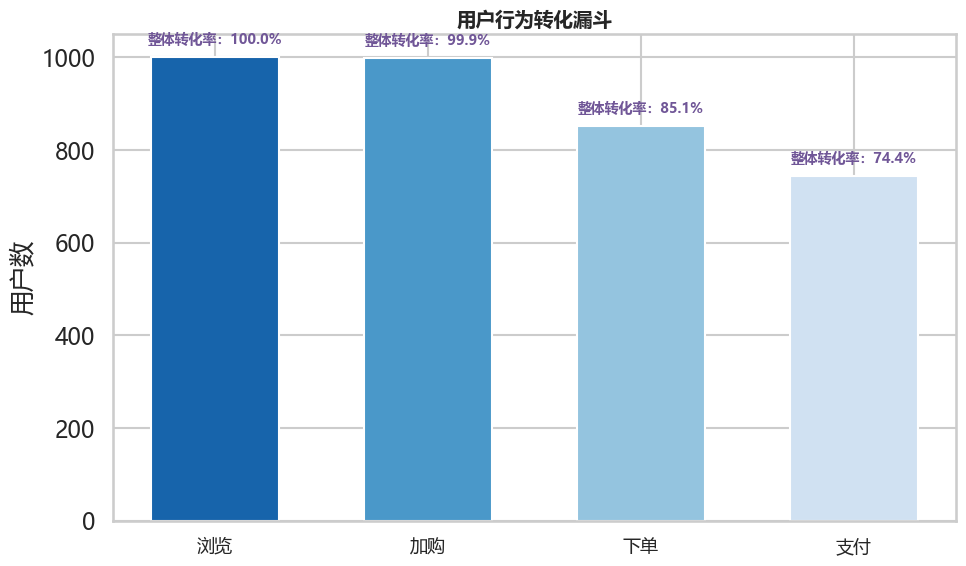

In [69]:
# 可视化
fig,ax = plt.subplots(figsize=(10,6))
colors = sns.color_palette('Blues_r', len(funnel_df))
bars =ax.bar(range(len(funnel_df)), funnel_df['user_count'], color=colors,
       edgecolor='white', width=0.6)
ax.set_xticks(range(len(funnel_df)))
ax.set_xticklabels(funnel_df['step_cn'], fontsize=13)
ax.set_title('用户行为转化漏斗', fontweight='bold', fontsize=14)
ax.set_ylabel('用户数')
# 开始设置x轴文字内容
for i,(_,row)  in  enumerate(funnel_df.iterrows()):
    y_offset = max(funnel_df['user_count']) * 0.02
    ax.text(i,row['user_count'] + y_offset,
            f"整体转化率：{row['overall_conversion_rate']:.1%}",
            ha='center', va='bottom', fontsize=10,
            fontweight='bold',color='#705697')
plt.tight_layout()
plt.show()

In [70]:
list(funnel_df.iterrows())


[(0,
  step                       view
  step_cn                      浏览
  user_count                 1000
  overall_conversion_rate     1.0
  step_conversion_rate        NaN
  Name: 0, dtype: object),
 (1,
  step                       add_to_cart
  step_cn                             加购
  user_count                         999
  overall_conversion_rate          0.999
  step_conversion_rate             0.999
  Name: 1, dtype: object),
 (2,
  step                       place_order
  step_cn                             下单
  user_count                         851
  overall_conversion_rate          0.851
  step_conversion_rate          0.851852
  Name: 2, dtype: object),
 (3,
  step                            pay
  step_cn                          支付
  user_count                      744
  overall_conversion_rate       0.744
  step_conversion_rate       0.874266
  Name: 3, dtype: object)]

In [71]:
# rfm模型构建
valid_orders = orders_df[orders_df['order_status'].isin(['paid', 'shipped', 'completed'])]
valid_orders.head()

,order_id,user_id,amount,order_status,create_time
0,1,433,74.15,completed,2025-01-01
1,2,239,528.12,paid,2025-01-01
2,3,734,118.71,completed,2025-01-01
4,5,7,231.72,paid,2025-01-01
5,6,782,45.19,completed,2025-01-01


In [72]:
# rfm模型构建


valid_orders = orders_df[orders_df['order_status'].isin(['paid', 'shipped', 'completed'])]
rfm_df = (valid_orders.groupby('user_id').agg(
    last_purchase=('create_time', 'max'),
    frequency=('order_id', 'nunique'),
    monetary=('amount', 'sum')
)
.reset_index())
now = pd.Timestamp.now()

rfm_df['recency'] = (now - rfm_df['last_purchase']).dt.days
rfm_df['frequency'] = rfm_df['frequency'].astype(int)
rfm_df['monetary'] = rfm_df['monetary'].astype(float)

rfm_df.head()

,user_id,last_purchase,frequency,monetary,recency
0,2,2025-01-29,2,99.03,496
1,3,2025-01-21,3,649.69,504
2,4,2025-01-15,1,40.43,510
3,5,2025-01-30,1,70.18,495
4,6,2025-01-14,2,551.57,511


In [75]:
# 对各个维度进行评分，进行打分
def safe_qcut(series, q, labels):
    """
    安全分箱: 解决 pd.qcut 处理大量重复值时的 ValueError
    详见学习指南 5.2 节的图解说明
    """
    try:
        # duplicates='drop': 如果分箱边界重复了，自动合并分箱
        result, bins = pd.qcut(series, q, labels=labels, retbins=True, duplicates='drop')
    except ValueError:
        # 如果还是失败，退化为等距分箱 pd.cut
        result, bins = pd.cut(series, bins=min(q, len(series.unique())),
                              labels=labels[:min(q, len(series.unique()))],
                              retbins=True, duplicates='drop')
    return result

rfm_df['r_score'] = safe_qcut(rfm_df['recency'], q=5, labels=list('54321'))
rfm_df['f_score'] = safe_qcut(rfm_df['frequency'], q=5, labels=list('12345'))
rfm_df['m_score'] = safe_qcut(rfm_df['monetary'], q=5, labels=list('12345'))
# print(rfm_df.head())

# 使用select进行评分划分，因为这个更快
score = rfm_df['r_score'].astype(int) + rfm_df['f_score'].astype(int) + rfm_df['m_score'].astype(int)
conditions = [score >=12, score >=9, score >=6]
choices = ['高价值客户', '中高价值客户', '中价值客户']

rfm_df['segment'] = np.select(conditions, choices, default='低价值客户')
print(rfm_df.head())

# 察看每种类型的用户的数量
segment_df = (rfm_df.groupby('segment').agg(
    user_count=('user_id', 'count'),
    recency=('recency', 'mean'),
    frequency=('frequency', 'mean'),
    monetary=('monetary', 'mean'),
)
.round(1))
segment_df.head()

   user_id last_purchase  frequency  monetary  recency r_score f_score  \
0        2    2025-01-29          2     99.03      496       5       1   
1        3    2025-01-21          3    649.69      504       3       2   
2        4    2025-01-15          1     40.43      510       2       1   
3        5    2025-01-30          1     70.18      495       5       1   
4        6    2025-01-14          2    551.57      511       2       1   

  m_score rfm_segment segment  
0       1       中价值客户   中价值客户  
1       5      中高价值客户  中高价值客户  
2       1       低价值客户   低价值客户  
3       1       中价值客户   中价值客户  
4       5       中价值客户   中价值客户  


,user_count,recency,frequency,monetary
segment,,,,
中价值客户,312,505.4,1.5,248.1
中高价值客户,192,500.0,2.3,484.3
低价值客户,192,515.3,1.1,107.4
高价值客户,48,497.4,3.9,700.6


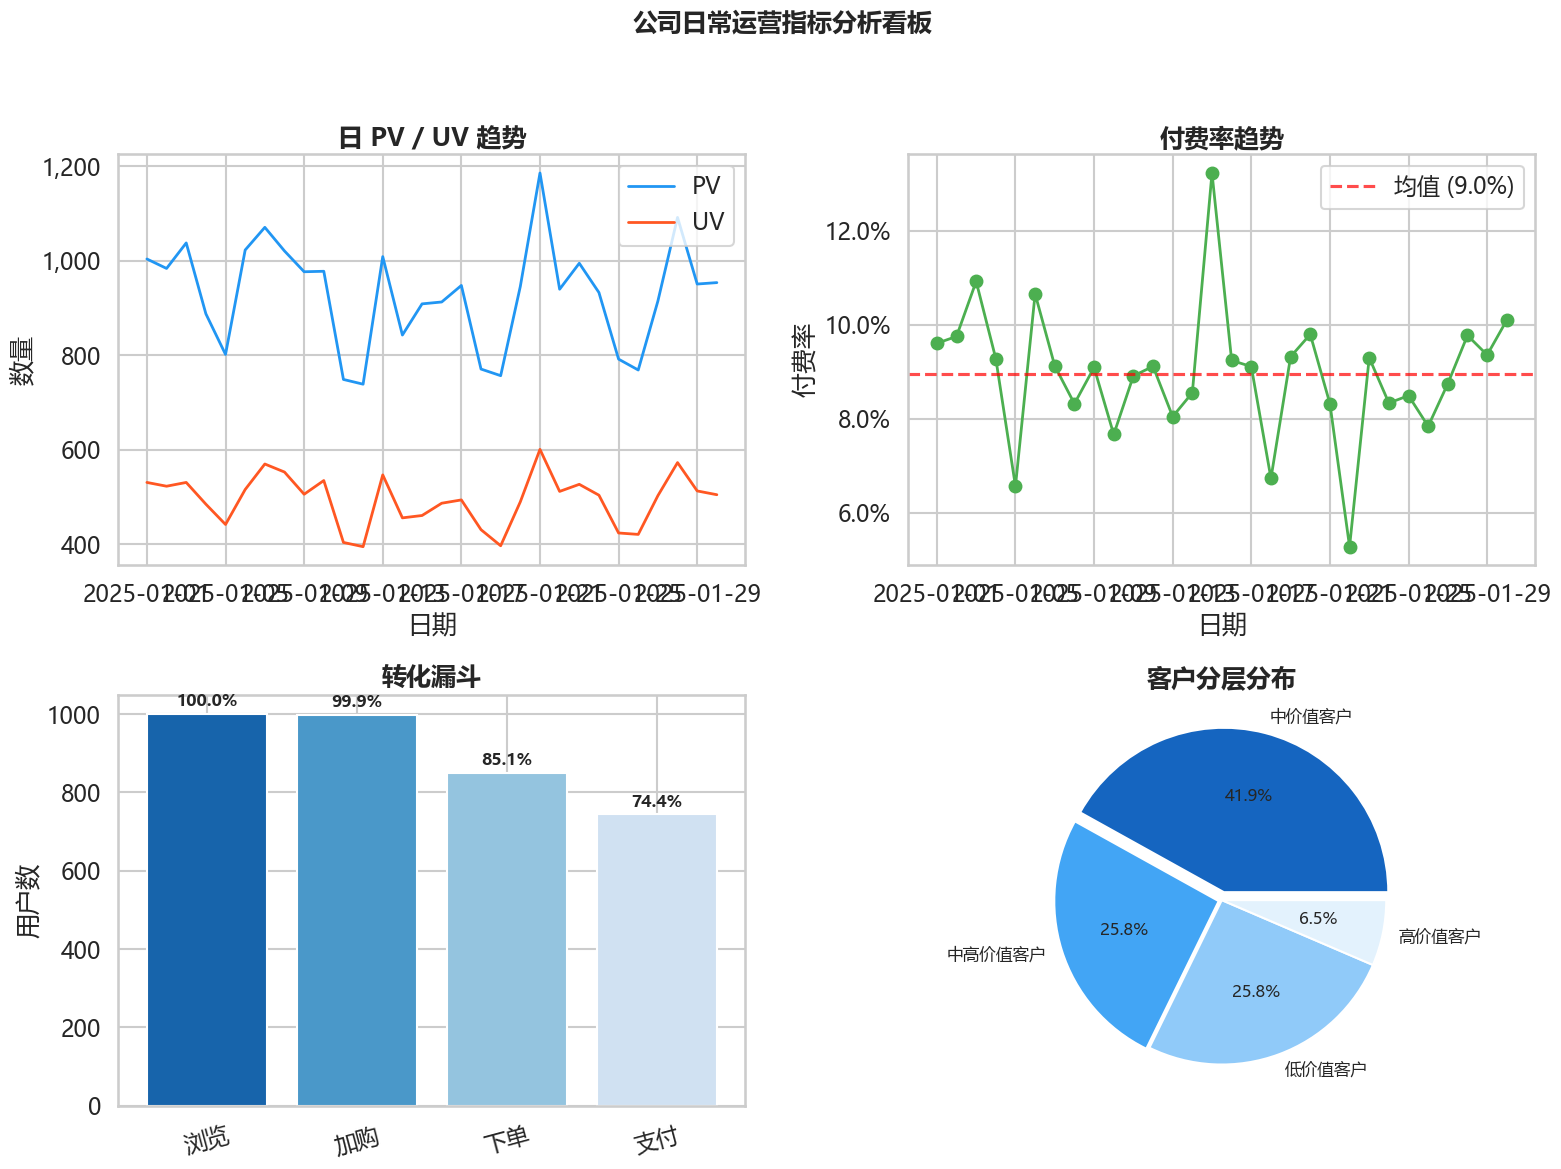

In [76]:
# 绘制综合面板，将上面的四张图片进行拼接，之后保存图片
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 图 1: PV/UV 趋势
ax = axes[0, 0]
ax.plot(pv_uv_df['date'], pv_uv_df['pv'], color='#2196F3', linewidth=2, label='PV')
ax.plot(pv_uv_df['date'], pv_uv_df['uv'], color='#FF5722', linewidth=2, label='UV')
ax.set_title('日 PV / UV 趋势', fontweight='bold')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlabel('日期'); ax.set_ylabel('数量')

# 图 2: 付费率趋势
ax = axes[0, 1]
ax.plot(pay_rate_df['date'], pay_rate_df['payment_rate'], color='#4CAF50', linewidth=2, marker='o')
ax.axhline(avg_pay_rate, color='red', linestyle='--', alpha=0.7, label=f'均值 ({avg_pay_rate:.1%})')
ax.set_title('付费率趋势', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel('日期'); ax.set_ylabel('付费率')

# 图 3: 漏斗分析
ax = axes[1, 0]
colors = sns.color_palette('Blues_r', len(funnel_df))
bars = ax.bar(range(len(funnel_df)), funnel_df['user_count'], color=colors, edgecolor='white')
ax.set_xticks(range(len(funnel_df)))
ax.set_xticklabels(funnel_df['step_cn'], rotation=15)
ax.set_title('转化漏斗', fontweight='bold')
ax.set_ylabel('用户数')
for i, (_, row) in enumerate(funnel_df.iterrows()):
    ax.text(i, row['user_count'] + max(funnel_df['user_count']) * 0.02,
            f"{row['overall_conversion_rate']:.1%}", ha='center', fontsize=12, fontweight='bold')

# 图 4: 客户分层饼图
ax = axes[1, 1]
seg_counts = rfm_df['segment'].value_counts()
colors_pie = ['#1565C0', '#42A5F5', '#90CAF9', '#E3F2FD']
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=colors_pie,
    explode=(0.05, 0.02, 0, 0),
    textprops={'fontsize': 12}
)
ax.set_title('客户分层分布', fontweight='bold')

fig.suptitle('公司日常运营指标分析看板', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('日常运营指标分析.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
# 关闭数据库连接
conn.close()